# Module 1 Experiment 1
● Apply the following tasks to any given dataset:
<ul> <li> Load and visualize data</li>
<li> Check out and replace missing values</li>
<li>Encode the Categorical data</li>
<li>Splitting the dataset into Training and Test set</li>
<li>Splitting the dataset into k-folds</li>
<li>Feature scaling</li>

### Loading and visualizing data

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Datasets/Diabetes Missing Data.csv") # Loading data

In [ ]:
df.head() # This will give first 5 rows in the dataframe

,Unnamed: 0,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Diabetes
1,1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,No Diabetes
2,2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Diabetes
3,3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,No Diabetes
4,4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetes


In [ ]:
df = df.drop(columns=['Unnamed: 0']) # Removing unnecessery column

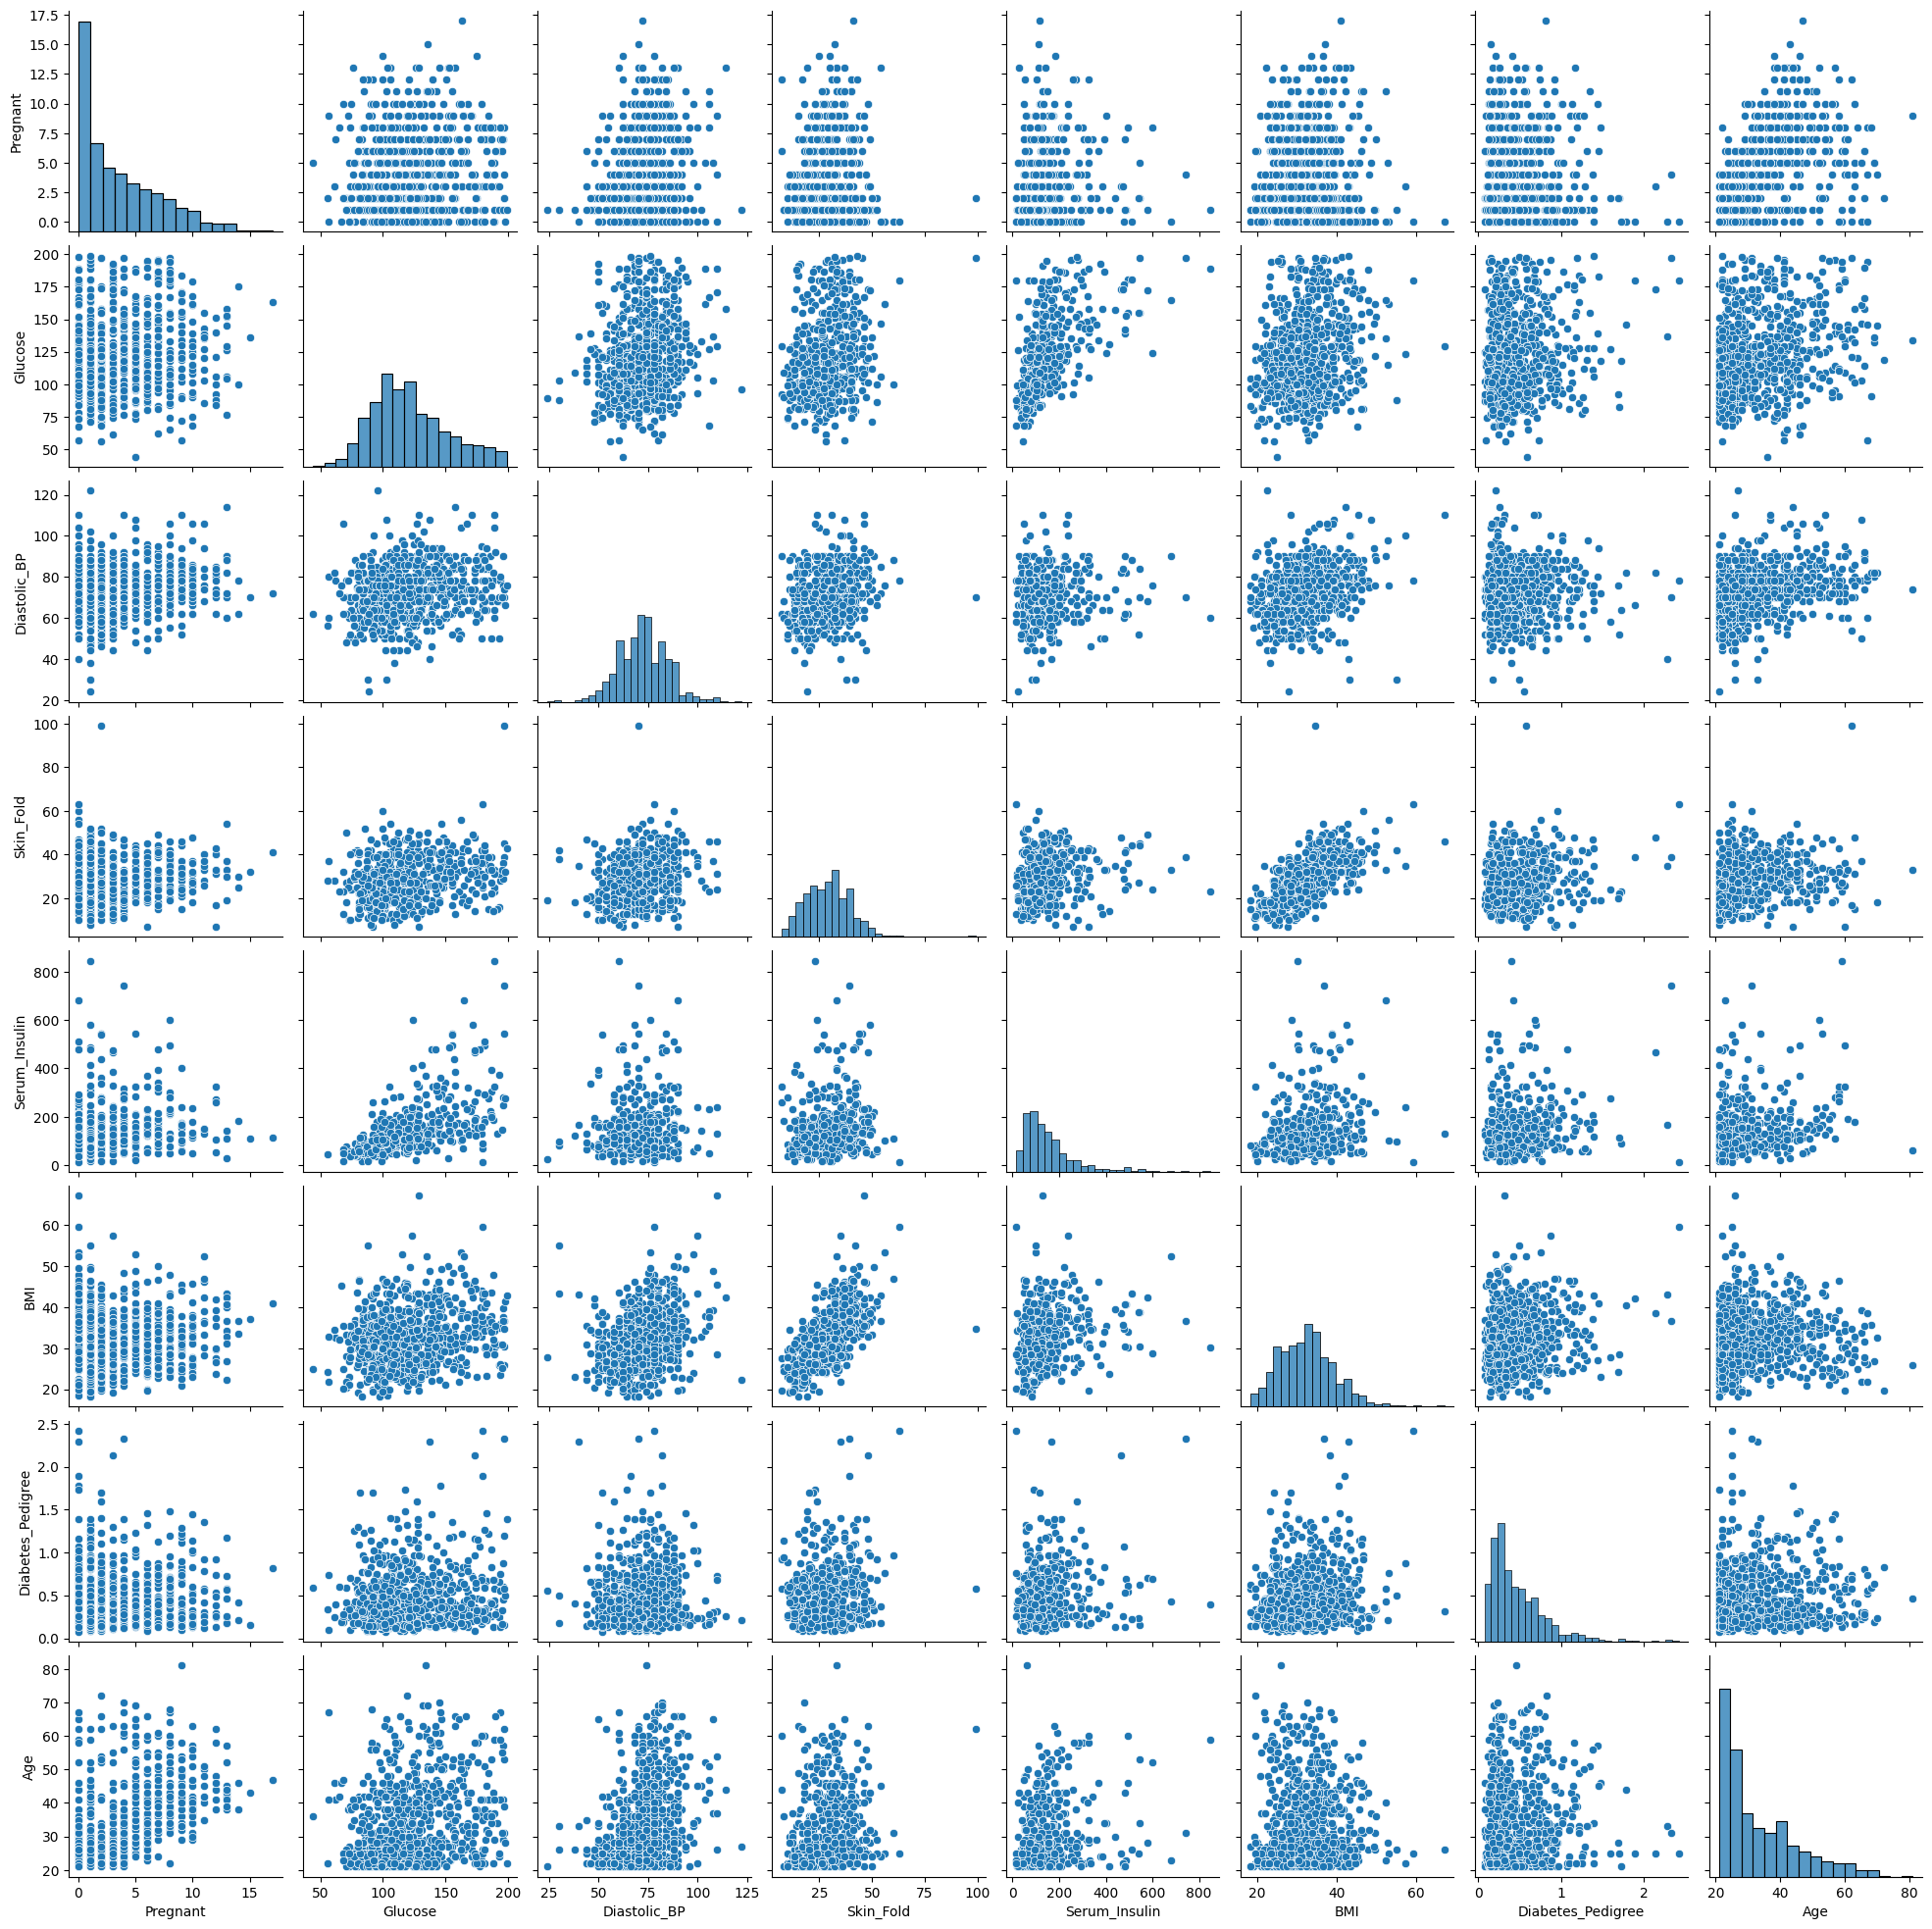

In [ ]:
import seaborn as sns
sns.pairplot(df) # This will give matrix of scatter plots that tells relationship of 2 attributes in the dataset

<Axes: >

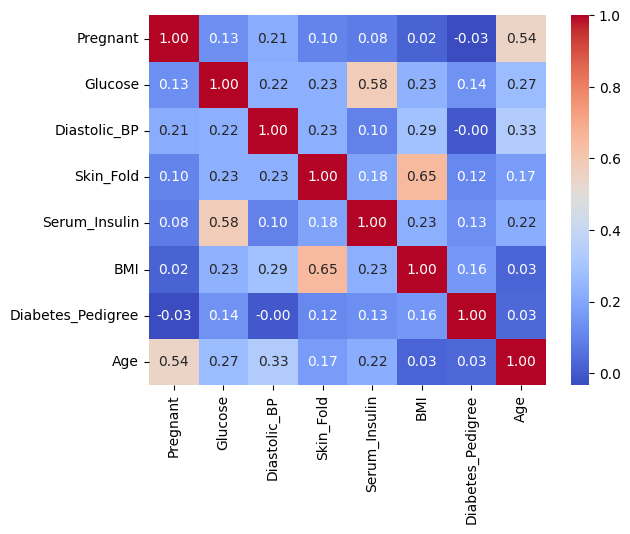

In [ ]:
corr_data = df.drop(columns=['Class'])
corr_data = corr_data.corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')

In [ ]:
df.isna() # Returns True is the value is null or Nan and false otherwise

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,False,False,False,False,True,False,False,False,False
1,False,False,False,False,True,False,False,False,False
2,False,False,False,True,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,True,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,True,True,False,False,False,False


In [ ]:
df.isna().sum() # This returns sum of null values in every feature

,0
Pregnant,0
Glucose,5
Diastolic_BP,35
Skin_Fold,227
Serum_Insulin,374
BMI,11
Diabetes_Pedigree,0
Age,0
Class,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.isna().sum().sum() # This function returns total null or NaN values present in the dataset

652

In [ ]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean()) # Filling NaN values present in feature glucose with its mean value
df.isna().sum()

,0
Pregnant,0
Glucose,0
Diastolic_BP,35
Skin_Fold,227
Serum_Insulin,374
BMI,11
Diabetes_Pedigree,0
Age,0
Class,0


In [ ]:
# Similar to glucose by replacing features
df['Diastolic_BP'] = df['Diastolic_BP'].fillna(df['Diastolic_BP'].mean())
df['Skin_Fold'] = df['Skin_Fold'].fillna(df['Skin_Fold'].median())  # Filling with median
df['Serum_Insulin'] = df['Serum_Insulin'].fillna(df['Serum_Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df.isna().sum()

,0
Pregnant,0
Glucose,0
Diastolic_BP,0
Skin_Fold,0
Serum_Insulin,0
BMI,0
Diabetes_Pedigree,0
Age,0
Class,0


### Categorical vs Numerical Data
<b>Categorical Data : </b>Categorical data refers to a data type that can be stored and identified based on the names or labels given to them. It is also known as qualitative data.<br>
Types of categorical data:


*   Nominal data : This is also called naming data. This type names or labels the data, and its characteristics are similar to a noun. <br>
  Example: person’s name, gender, school name.
*   Ordinal data : This includes data or elements of data that are ranked, ordered, or used on a rating scale. You can count and order ordinal data, but it doesn’t allow you to measure it.<br>
Example: seminar attendants are asked to rate their seminar experience on a scale of 1-5. Against each number, there will be options that will rate their satisfaction, such as “very good, good, average, bad, and very bad.”


<b>Numerical Data : </b>Numerical data refers to the data that is in the form of numbers, and not in any language or descriptive form. It is also known as qunatiative data.<br>
Types of numerical data:
*  Discrete data : Discrete data is used to represent countable items. It can take both numerical and categorical forms and group them into a list. This list can be finite or infinite, too. <br>
Example: counting sugar cubes from a jar is finite countable. But counting sugar cubes from all over the world is infinitely countable.

*   Continous data : As the name says, this form has data in the form of intervals. Or simply said ranges.<br>
Example: 5-10, 20-100

<a href=https://www.voxco.com/blog/categorical-data-vs-numerical-data/>Reference</a>



In machine learning algorithm can't handle categorical data. So, we encode the categorical data using some pre-defined funtions in python.
For example if classes are ["Happy", "Sad", "Angry", "Angry", "Happy"], we can encode by assigning an integer to each class like <br>
Happy - 0<br>
Sad  - 1 <br>
Angry - 2 <br>
Now the encode array of classes will be [0, 1, 2, 2, 0]

In [ ]:
from sklearn.preprocessing import LabelEncoder # Pre-defined function for encoding labels
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
df

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,105.000000,33.6,0.627,50,0
1,1,85.0,66.0,29.0,155.420253,26.6,0.351,31,1
2,8,183.0,64.0,29.0,155.420253,23.3,0.672,32,0
3,1,89.0,66.0,23.0,94.000000,28.1,0.167,21,1
4,0,137.0,40.0,35.0,168.000000,43.1,2.288,33,0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.000000,32.9,0.171,63,1
764,2,122.0,70.0,27.0,155.420253,36.8,0.340,27,1
765,5,121.0,72.0,23.0,112.000000,26.2,0.245,30,1
766,1,126.0,60.0,29.0,155.420253,30.1,0.349,47,0


To train a model we should seperate the data in feature set and target set. Feature set are data that are passed as input and they are idependent variables. When in comes to target set, they are output labels and they are dependent on independent data. Let's take x as feature set and y as target set.

In [ ]:
x = df.drop(columns=['Class'])
y = df['Class']

Spliting into training and testing data is important to see the model peformance on unseen data. We can split the data using pre-defined function in python.

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, shuffle=True)  # 0.2 means dividing 20% data as test data

In [ ]:
print("x_train shape : ",x_train.shape)
print("x_test shape : ",x_test.shape)
print("y_train shape : ",y_train.shape)
print("y_test shape : ",y_test.shape)

x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)


### Cross validation
Cross validation is a method used in machine learning to train models not to overfit it means performing well on training data and poorly on testing data.
Types of cross validations are :

*   Holdout Validation: we perform training on the 50% of the given dataset and rest 50% is used for the testing purpose.
*   LOOCV (Leave One Out Cross Validation): In LOOCV, the model is trained on
n−1 samples and tested on the one omitted sample, repeating this process for each data point in the dataset.

*   Stratified Cross-Validation: It is a technique used in machine learning to ensure that each fold of the cross-validation process maintains the same class distribution as the entire dataset.
*   K-Fold Cross Validation: we split the dataset into k number of subsets (known as folds) then we perform training on the all the subsets but leave one(k-1) subset for the evaluation of the trained model.

<a href = "https://www.geeksforgeeks.org/cross-validation-machine-learning/">
Reference</a>




In [ ]:
# Kfold cross validation
from sklearn.model_selection import KFold
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

for train_index, test_index in kf.split(x):

  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  print("x_train shape : ", x_train.shape)
  print("x_test shape : ", x_test.shape)
  print("y_train shape : ", y_train.shape)
  print("y_test shape : ", y_test.shape)
  print()

x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)

x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)

x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)

x_train shape :  (615, 8)
x_test shape :  (153, 8)
y_train shape :  (615,)
y_test shape :  (153,)

x_train shape :  (615, 8)
x_test shape :  (153, 8)
y_train shape :  (615,)
y_test shape :  (153,)



<generator object _BaseKFold.split at 0x7e172e9f5af0>

### Feature scaling
Feature scaling is a process performed on data while pre-processing to reduce the data into a fixed range. Few ways for feature scaling are:


*   Min-Max scaling:

  *   First, we are supposed to find the minimum and the maximum value of the column.

  *  Then we will subtract the minimum value from the entry and divide the result by the difference between the maximum and the minimum value.
  The Min-Max Scaling formula is:

$$
X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
$$

Where:
- \( X \) is the original value of the feature.
- \( X_{\text{min}} \) is the minimum value of the feature.
- \( X_{\text{max}} \) is the maximum value of the feature.
- \( X_{\text{scaled}} \) is the scaled value, which will lie between 0 and 1.
<br>




Normalization: This method is more or less the same as the previous method but here instead of the minimum value, we subtract each entry by the mean value of the whole data and then divide the results by the difference between the minimum and the maximum value.
The Normalization formula is:

$$
X_{\text{normalized}} = \frac{X - X_{\text{mean}}}{X_{\text{max}} - X_{\text{min}}}
$$

Where:
- \( X \) is the original value of the feature.
- \( X_{\text{mean}} \) is the minimum value of the feature.
- \( X_{\text{max}} \) is the maximum value of the feature.
- \( X_{\text{normalized}} \) is the normalized value, which will lie between 0 and 1.


Standardization:
This method of scaling is basically based on the central tendencies and variance of the data.


*   First, we should calculate the mean and standard deviation of the data we would like to normalize.
*   Then we are supposed to subtract the mean value from each entry and then divide the result by the standard deviation.

We will obtain normal distribution of the data with mean 0 and standard deviation 1.

The **Standardization** (Z-score normalization) formula is:

$$
X_{\text{standardized}} = \frac{X - \mu}{\sigma}
$$

Where:
- \( X \) is the original value of the feature.
- \( \mu \) is the mean of the feature.
- \( \sigma \) is the standard deviation of the feature.
- \( X_{\text{standardized}} \) is the standardized value, which will have a mean of 0 and a standard deviation of 1.

<a href="https://www.geeksforgeeks.org/ml-feature-scaling-part-2/">Reference<a>




In [ ]:
# Min-Max scaling
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
mms_data = mms.fit_transform(df)
mms_data = pd.DataFrame(mms_data, columns=df.columns)
mms_data.head()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0.352941,0.670968,0.489796,0.304348,0.109375,0.314928,0.234415,0.483333,0.0
1,0.058824,0.264516,0.428571,0.239130,0.169976,0.171779,0.116567,0.166667,1.0
2,0.470588,0.896774,0.408163,0.239130,0.169976,0.104294,0.253629,0.183333,0.0
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,1.0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,0.0


In [ ]:
# Normalization
from sklearn.preprocessing import Normalizer
norm = Normalizer()
norm_data = norm.fit_transform(df)
norm_data = pd.DataFrame(norm_data, columns=df.columns)
norm_data.head()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0.028933,0.713692,0.347201,0.168778,0.506335,0.162027,0.003024,0.241112,0.000000
1,0.005113,0.434624,0.337473,0.148284,0.794699,0.136012,0.001795,0.158510,0.005113
2,0.031570,0.722171,0.252563,0.114442,0.613334,0.091949,0.002652,0.126281,0.000000
3,0.006612,0.588455,0.436382,0.152073,0.621514,0.185793,0.001104,0.138849,0.006612
4,0.000000,0.596386,0.174127,0.152361,0.731335,0.187622,0.009960,0.143655,0.000000


In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss_data = ss.fit_transform(df)
ss_data = pd.DataFrame(ss_data, columns=df.columns)
ss_data.head()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0.639947,0.865108,-0.033518,0.670643,-0.593282,0.166292,0.468492,1.425995,-1.365896
1,-0.844885,-1.206162,-0.529859,-0.012301,0.000000,-0.852531,-0.365061,-0.190672,0.732120
2,1.233880,2.015813,-0.695306,-0.012301,0.000000,-1.332833,0.604397,-0.105584,-1.365896
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.722717,-0.634212,-0.920763,-1.041549,0.732120
4,-1.141852,0.503458,-2.680669,0.670643,0.148023,1.548980,5.484909,-0.020496,-1.365896
